# Multi-Asset Allocation

## Data

This problem uses `weekly` data from `data/asset_class_etf_data.xlsx`.
* tab `excess returns`: weekly returns net of cash (`SHV`)
* tab `descriptions`: what each ticker holds

One fund per asset class, built across the course:
* equities: `SPY`, `VEA`
* bonds and credit: `IEF`, `HYG`
* commodities: `GLD`, `USO`
* crypto: `BTC`

`BTC` is the spot bitcoin series. It became investable in ETF form in late 2021 (`BITO`, futures-based) and via spot ETFs (`IBIT`, `FBTC`) in January 2024. The out-of-sample window below starts in 2022: the ETF era.

Annualize weekly stats with a factor of `52`.

# 1 The Asset Menu

## 1.1

For each asset, calculate over the full sample the annualized
* mean
* volatility
* Sharpe ratio

## 1.2

Report the correlation matrix.

Which asset offers the most diversification against `SPY`?

## 1.3

Report each asset's empirical VaR (.05) of weekly returns.

Which assets carry the most tail risk?

,Annualized Return,Annualized Excess Return,Annualized Volatility,Sharpe Ratio
SPY,0.138232,0.138214,0.174663,0.791322
VEA,0.081996,0.081978,0.173244,0.473192
IEF,-0.008569,-0.008587,0.063641,-0.134930
HYG,-0.004677,-0.004695,0.096553,-0.048625
GLD,0.138651,0.138633,0.151405,0.915641
USO,0.099176,0.099158,0.409988,0.241856
BTC,0.675898,0.675880,0.687931,0.982482


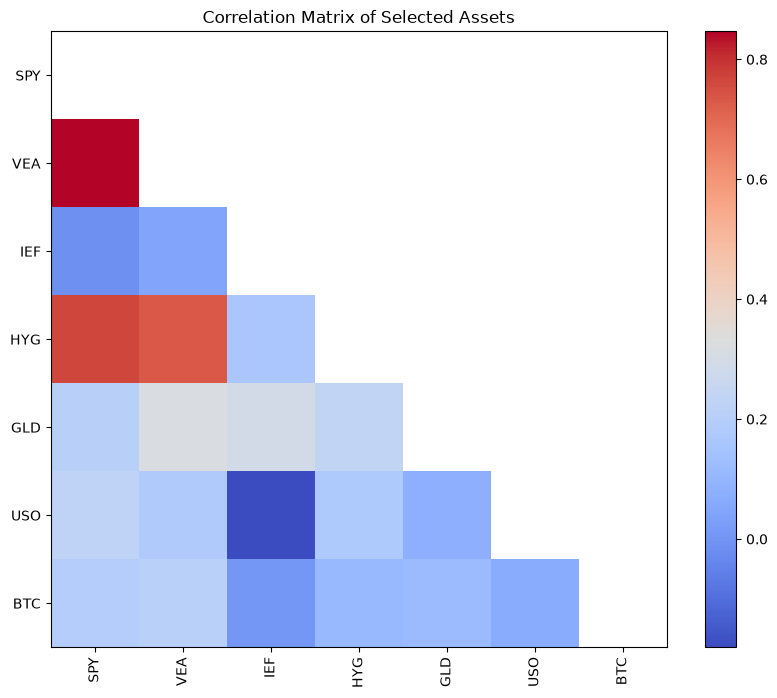

SPY   -0.032704
VEA   -0.034911
IEF   -0.015835
HYG   -0.015587
GLD   -0.031070
USO   -0.082074
BTC   -0.137061
Name: 0.05, dtype: float64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.1
prices = pd.read_excel('./data/asset_class_etf_data.xlsx', sheet_name='prices', index_col=0).drop(columns=["SHV"])
all_returns = pd.read_excel('./data/asset_class_etf_data.xlsx', sheet_name='total returns', index_col=0)
returns = all_returns.drop(columns=["SHV"])
shv_returns = all_returns["SHV"]
excess = pd.read_excel('./data/asset_class_etf_data.xlsx', sheet_name='excess returns', index_col=0)

# Calculate annualized numbers
annualized_returns = returns.mean() * 52
annualized_excess_returns = excess.mean() * 52
annualized_volatility = returns.std() * np.sqrt(52)
sharpe_ratio = annualized_excess_returns / annualized_volatility

# Table to present results
results = pd.DataFrame({
    'Annualized Return': annualized_returns,
    'Annualized Excess Return': annualized_excess_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio
})

display(results)

# 1.2 correlation matrix by heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = returns.corr()
# Create a mask to show only the lower triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Apply the mask and plot
plt.imshow(correlation_matrix.mask(mask), cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix of Selected Assets')
plt.show()
mask

#1.3 Report each asset's empirical VaR (.05) of weekly returns.
var_05 = returns.quantile(0.05)
display(var_05)

**Answer 1.2:** IEF offers the most diversification against SPY.

**Answer 1.3:** Overall, USO and BTC has the most tail risk with VaR 0.05 being -0.082 and -0.137.

***

# 2 Simple Rules

Two portfolios that require no optimization:
* equally-weighted across the 7 assets, rebalanced weekly
* `60/40`: 60% `SPY`, 40% `IEF`, rebalanced weekly

## 2.1

For each, report the annualized mean, volatility, and Sharpe over the full sample.

## 2.2

Report each portfolio's empirical VaR (.05). Compare to the individual assets in 1.3.

In [3]:
# Initialize portfolio weights for each strategy
# Portfolio A: Equally-weighted, rebalanced weekly
weights_A = pd.Series([1/len(returns.columns)] * len(returns.columns), index=returns.columns)
# Portfolio B: 60%SPY, 40% IEF, rebalanced weekly
weights_B = pd.Series([0.6, 0, 0.4] + [0] * (len(returns.columns) - 3), index=returns.columns)

# Calculate weekly portfolio returns
portfolio_returns = pd.DataFrame({
    "Equal Weight": returns @ weights_A,
    "60/40 SPY/IEF": returns @ weights_B
})

portfolio_excess = pd.DataFrame({
    "Equal Weight": excess @ weights_A,
    "60/40 SPY/IEF": excess @ weights_B
})

# 2.1 Metrics
portfolio_cagr = portfolio_returns.mean() * 52
portfolio_excess_returns = portfolio_excess.mean() * 52
portfolio_volatility = portfolio_returns.std() * np.sqrt(52)

portfolio_metrics = pd.DataFrame({
    "Annualized Return": portfolio_cagr,
    "Annualized Excess Return": portfolio_excess_returns,
    "Annualized Volatility": portfolio_volatility,
    "Sharpe Ratio": portfolio_excess_returns / portfolio_volatility
})
display(portfolio_metrics)

# 2.2 Empirical weekly VaR at 5%
portfolio_var_05 = portfolio_returns.quantile(0.05)
display(portfolio_var_05)

,Annualized Return,Annualized Excess Return,Annualized Volatility,Sharpe Ratio
Equal Weight,0.160101,0.160083,0.151766,1.054803
60/40 SPY/IEF,0.079512,0.079494,0.107530,0.739274


Equal Weight    -0.028594
60/40 SPY/IEF   -0.021378
Name: 0.05, dtype: float64

**Answer 2.2:** The diversified portfolios have much less tail risk using VaR 0.05 as the metric, compared to the individual assets (excpet for IEF and HYG, which are bonds). The equal weight portfolio even has an annualized mean return higher than all assets except BTC with such small tail risk. 

***

# 3 Mean-Variance Optimization

Estimate using data **through 2021 only**. (2022 onward is held out for Section 5.)

Exclude `BTC` for this section: the menu is the 6 traditional assets.

## 3.1

Calculate the tangency portfolio weights.

$$
\mathbf{w}_{\mathrm{tan}}
=
\frac{\Sigma^{-1}\mu}
{\mathbf{1}^{\top}\Sigma^{-1}\mu}
$$

## 3.2

Do the weights look like a portfolio you could hold? Note any extreme or short positions.

## 3.3

Report the in-sample (through 2021) annualized mean, volatility, and Sharpe of the tangency portfolio, alongside the equal-weight and `60/40` portfolios over the same window.

In [29]:
# keep only data through 2021 without BTC
returns_part3 = returns.copy().drop(columns = "BTC").drop(returns[returns.index.year > 2021].index)
excess_part3 = excess.copy().drop(columns = "BTC").drop(excess[excess.index.year > 2021].index)
annualized_returns_part3 = returns_part3.mean() * 52 # number

# 3.1 Tangency portfolio weights
cov_matrix = data_part3.cov() * 52  # Annualized covariance matrix
inv_cov_matrix = np.linalg.inv(cov_matrix)
tangency_weights = inv_cov_matrix @ annualized_returns_part3 / (np.ones(len(annualized_returns_part3)) @ inv_cov_matrix @ annualized_returns_part3)
print(pd.DataFrame(tangency_weights, index=annualized_returns_part3.index, columns=["Weights"]))

# 3.2 See below

# 3.2 Calculate the expected return and volatility of the tangency portfolio and overlay with the previous portfolios
tangency_returns = (returns_part3 @ tangency_weights).mean() * 52
tangency_excess = (excess_part3 @ tangency_weights).mean() * 52
tangency_volatility = (returns_part3 @ tangency_weights).std() * np.sqrt(52)
tangency_sharpeRatio = tangency_excess / tangency_volatility

portfolio_metrics.loc["Tangency (ex-BTC)"] = {
    "Annualized Return": tangency_returns,
    "Annualized Excess Return": tangency_excess,
    "Annualized Volatility": tangency_volatility,
    "Sharpe Ratio": tangency_sharpeRatio
}

display(portfolio_metrics)



      Weights
SPY  1.983906
VEA -0.827804
IEF  1.053631
HYG -1.567881
GLD  0.403882
USO -0.045735


,Annualized Return,Annualized Excess Return,Annualized Volatility,Sharpe Ratio
Equal Weight,0.160101,0.160083,0.151766,1.054803
60/40 SPY/IEF,0.079512,0.079494,0.107530,0.739274
Tangency (ex-BTC),0.311041,0.310890,0.170346,1.825053


**Answer 3.2:** This is a mathematically feasible portfolio despite the high leverage in both long and short positions. The portfolio longs SPY with 198% weights, which is almost a 2x leverge, and shorting assets like VEA, HYG, and USO. Even though the portfolio sums to 1, it is not practical especially for retail investors since brokers would not allow an exposure over 500%, short and long together. 

***

# 4 A New Asset Class

Now add `BTC` to the menu. Still estimating through 2021 only.

## 4.1

Recalculate the tangency weights with all 7 assets.

How large is the `BTC` allocation?

## 4.2

Using `BTC`'s through-2021 mean, volatility, and correlations, explain why the optimizer sizes it the way it does.

## 4.3

Would you take this allocation to an investment committee? What would you have to believe about the *future* mean of `BTC` for it to be justified?

***

# 5 Out of Sample

Hold the weights estimated through 2021 fixed. Evaluate on 2022 through mid-2026: the ETF era.

## 5.1

For four portfolios,
* tangency (ex-`BTC`)
* tangency (with `BTC`)
* equal-weight
* `60/40`

report the out-of-sample annualized mean, volatility, and Sharpe.

## 5.2

Compare the in-sample and out-of-sample rankings. Which portfolio would you actually have wanted to hold?

## 5.3

Does the out-of-sample result vindicate or indict the optimizer? Careful: one out-of-sample window is itself a small sample.

***

# 6 Fragility

## 6.1

Re-estimate the tangency weights (all 7 assets) on rolling 3-year (156-week) windows. Plot the weights through time.

## 6.2

Estimate the tangency weights on two subsamples: 2017-2019 and 2020-2021. Report both sets side by side.

## 6.3

The math of mean-variance is exact; the inputs are estimates.
* Which input is the bigger problem: the means or the covariance matrix?
* Given 6.1 and 6.2, why do practitioners constrain weights, shrink estimates, or fall back to simple rules?